In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from random import randrange
from mpl_toolkits.mplot3d import Axes3D
#balíčky

In [2]:
def ntaylor(b,x1,x2,r,v,c):

    b1, b2 = b #souradnice clusteru
    f= np.cos((b1*np.pi)/5)*np.sin((b2*np.pi)/3) #puvodni funkce
    
    d_b1= np.cos((b1*np.pi+v)/5)*np.sin((b2*np.pi)/3)
    d_b2= np.cos((b1*np.pi)/5)*np.sin((b2*np.pi+v)/3)
    
    p_b1 = np.cos((b1*np.pi-v)/5)*np.sin((b2*np.pi)/3)
    p_b2 = np.cos((b1*np.pi)/5)*np.sin((b2*np.pi-v)/3)
    
    fb1 = (d_b1 - p_b1)/(2*v)
    fb2 = (d_b2 - p_b2)/(2*v)   #centralni diference

    fb1b1 = (d_b1 - 2*f + p_b1)/v**2
    fb2b2 = (d_b2 - 2*f + p_b2)/v**2

    dx1 = x1 - b1
    dx2 = x2 - b2         #vzdalenost stredu
    
    if r == 1:
        taylor= f + fb1*(x1 - b1) + fb2*(x2 - b2)
    else:
        taylor= f +  fb1*(x1 - b1) + fb2*(x2 - b2) +(fb1b1/2*(x1-b1)**2) +(fb2b2/2*(x2-b2)**2)
    return taylor
#funkce b=stred clustery, v=krok derivace

In [3]:
x1 = np.linspace(-3, 4*np.pi, 100)
x2 = np.linspace(-3, 4*np.pi, 100)
x1,x2 = np.meshgrid(x1,x2)

y=np.cos((x1*np.pi)/5)*np.sin((x2*np.pi)/3)

In [4]:
points = np.column_stack((x1.ravel(), x2.ravel()))

k = 4
kmeans = KMeans(n_clusters=k, random_state=0).fit(points)

centers = kmeans.cluster_centers_
b = [tuple(float(round(x, 2)) for x in c) for c in centers]

print('Centra clusteru:', b)

Centra clusteru: [(8.76, 0.9), (0.81, 8.67), (0.9, 0.8), (8.67, 8.76)]


In [5]:
r = int(input('Zadej řád derivace: '))
v = float(input('Zadej krok num. derivace: '))
#vstupy

Zadej řád derivace:  2
Zadej krok num. derivace:  1


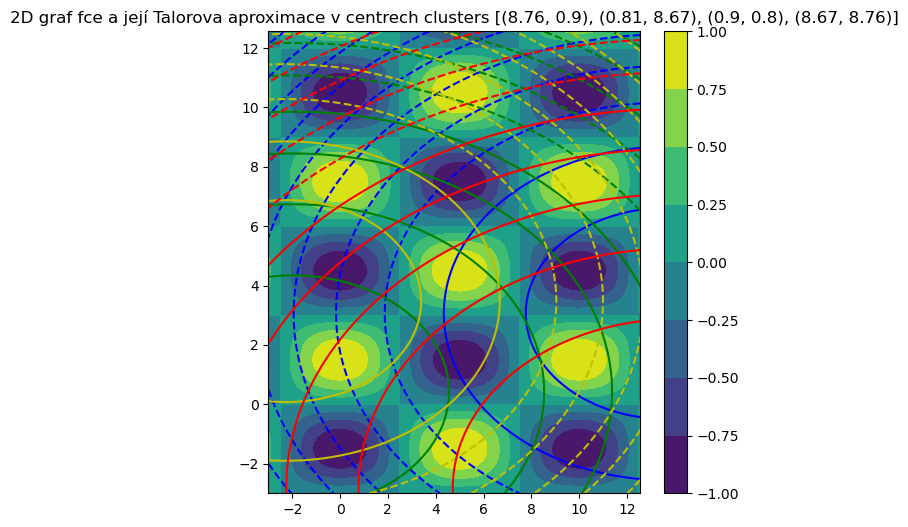

In [6]:

plt.figure(figsize=(6,6))
plt.contourf(x1,x2,y)
plt.colorbar()

colours = ['b','g','y','r']

for i in range(len(b)) :
    yn = ntaylor(b[i],x1, x2,r,v,c=colours[i])
    
    cs = plt.contour(x1, x2, yn, levels=10, colors=colours[i])
   
plt.title('2D graf fce a její Talorova aproximace v centrech clusters {}' .format(b))
plt.show()

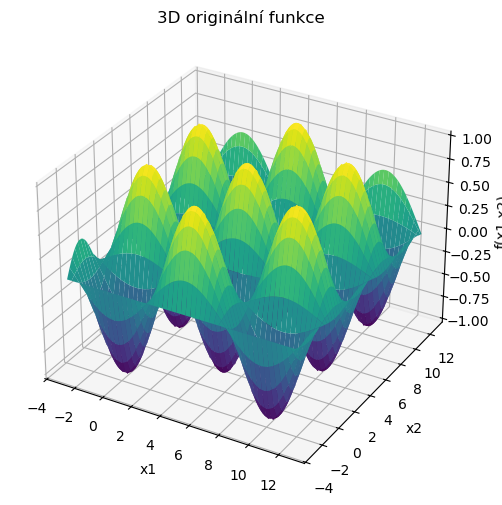

In [7]:

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1, x2, y, cmap='viridis')
ax.set_title("3D originální funkce")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1,x2)")

plt.show()

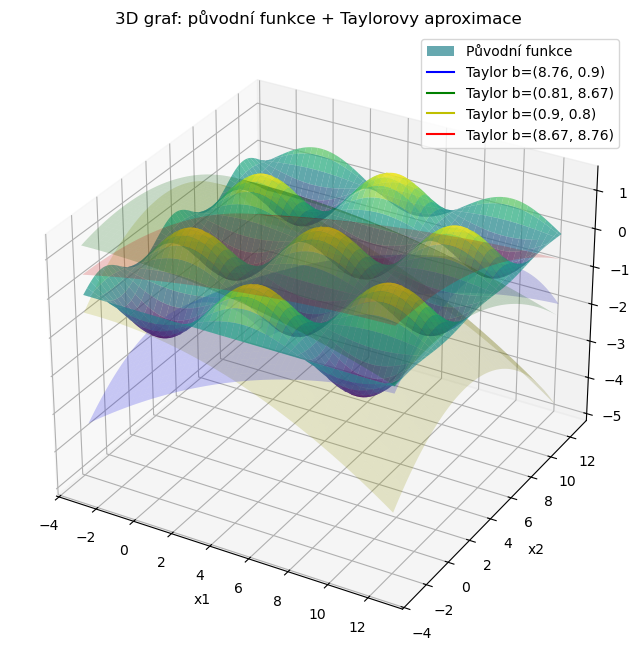

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1, x2, y, cmap='viridis', alpha=0.7, label='Původní funkce')

for i in range(len(b)):
    yn = ntaylor(b[i], x1, x2, r, v, c=colours[i])
    ax.plot_surface(x1, x2, yn, color=colours[i], alpha=0.2)
    ax.plot([], [], color=colours[i], label=f"Taylor b={b[i]}")

ax.set_title("3D graf: původní funkce + Taylorovy aproximace")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1, x2)")

plt.legend()
plt.show()

In [9]:
#vytvořit 4 body Z


N=4
Z1 = np.random.uniform(-3, 4*np.pi,N)
Z2 = np.random.uniform(-3, 4*np.pi,N)
body = np.column_stack((Z1,Z2))
body = np.round((body),2)

print('BODY:', body)

BODY: [[ 8.89  3.69]
 [10.31 -2.63]
 [-2.82  1.66]
 [-0.37 10.8 ]]


In [10]:
#spočítat vzdalenosti bodu Z a vybrat nejmenší

vzdalenosti = []

for b1, b2 in b:
    vz = np.sqrt((body[:,0]-b1)**2 + (body[:,1]-b2)**2)
    vzdalenosti.append(vz)
    
vzdalenosti = np.array(vzdalenosti) #vzdalenost pro kazdy bod

nejblizsi_center = np.argmin(vzdalenosti, axis=0) #vyhodnocení nejmenší vzdálenosti
print('centra pro body', nejblizsi_center)

centra pro body [0 0 2 1]


In [11]:
#spočítat hodnotu Z v této aproximaci
#zobrazit bod v grafu
hodnota = []

for i in range(len(body)):
    idx = nejblizsi_center[i]
    Z1, Z2 = body[i]
    hodnota.append(ntaylor(b[idx], Z1, Z2, r, v,None))

print('Hodnoty aproximace:', hodnota)


Hodnoty aproximace: [np.float64(0.7252821832789854), np.float64(-0.15475554131005162), np.float64(0.8820936658112173), np.float64(-0.32019914554526613)]


[8.89 3.69] 0.7252821832789854


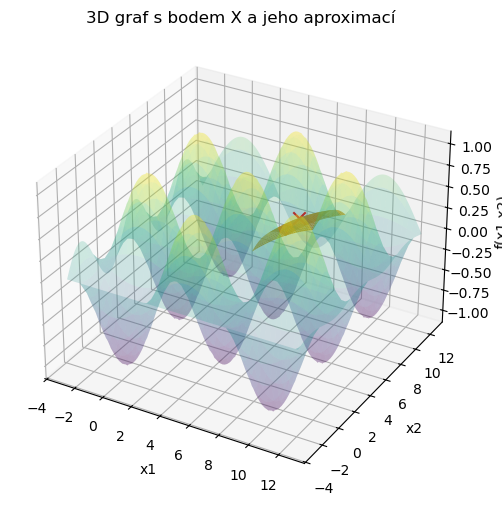

In [12]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1, x2, y, cmap='viridis', alpha=0.2)

X = body[0]
Z = hodnota[0]

print(X,Z)
ax.scatter(X[0], X[1], Z, color='red', s=80, marker='x')

# lokální mřížka kolem bodu X
xx = np.linspace(X[0]-2, X[0]+2, 60)
yy = np.linspace(X[1]-2, X[1]+2, 60)
xx, yy = np.meshgrid(xx, yy)

# Taylorova aproximace v této malé oblasti
zz = ntaylor(b[nejblizsi_center[0]], xx, yy, r, v,None)

# vykreslení Taylorovy plochy
ax.plot_surface(xx, yy, zz, color='orange', alpha=0.9)


ax.set_title("3D graf s bodem X a jeho aproximací")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1,x2)")

plt.show()